<a href="https://colab.research.google.com/github/Satish1895/6thSem-ML-Lab/blob/main/Lab7_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#SVM (Support Vectore Machine)

from google.colab import files
uploaded = files.upload()

import pandas as pd
import numpy as np
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier
import matplotlib.pyplot as plt

Saving iris.csv to iris (1).csv
Saving letter-recognition.csv to letter-recognition (1).csv


In [ ]:
print("===== IRIS DATASET =====")

iris_df = pd.read_csv("iris (1) (2).csv")

X_iris = iris_df.iloc[:, :-1]
y_iris = iris_df.iloc[:, -1]

X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42
)

===== IRIS DATASET =====


In [ ]:
linear_model = svm.SVC(kernel='linear')
linear_model.fit(X_train_i, y_train_i)

y_pred_linear = linear_model.predict(X_test_i)

print("\n--- Linear Kernel ---")
print("Accuracy:", accuracy_score(y_test_i, y_pred_linear))
print("Confusion Matrix:\n", confusion_matrix(y_test_i, y_pred_linear))


--- Linear Kernel ---
Accuracy: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [ ]:
rbf_model = svm.SVC(kernel='rbf')
rbf_model.fit(X_train_i, y_train_i)

y_pred_rbf = rbf_model.predict(X_test_i)

print("\n--- RBF Kernel ---")
print("Accuracy:", accuracy_score(y_test_i, y_pred_rbf))
print("Confusion Matrix:\n", confusion_matrix(y_test_i, y_pred_rbf))


--- RBF Kernel ---
Accuracy: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [ ]:


print("\n\n===== LETTER RECOGNITION DATASET =====")

# Load correctly (WITH header)
letter_df = pd.read_csv("letter-recognition.csv")

X = letter_df.iloc[:, 1:]
y = letter_df.iloc[:, 0]

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)



===== LETTER RECOGNITION DATASET =====


In [ ]:
#Random Forest
# =========================================
# STEP 1: Import Libraries
# =========================================
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix

# =========================================
# STEP 2: Load Dataset (iris.csv)
# =========================================
data = pd.read_csv("iris.csv")

# Display first few rows
print(data.head())

# =========================================
# STEP 3: Preprocessing
# =========================================
# Encode target column (species)
le = LabelEncoder()
data['species'] = le.fit_transform(data['species'])

# Features & Target
X = data.drop('species', axis=1)
y = data['species']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# =========================================
# STEP 4: Random Forest (Default n_estimators = 10)
# =========================================
rf_default = RandomForestClassifier(n_estimators=10, random_state=42)
rf_default.fit(X_train, y_train)

y_pred_default = rf_default.predict(X_test)

accuracy_default = accuracy_score(y_test, y_pred_default)
cm_default = confusion_matrix(y_test, y_pred_default)

print("\n=== Default Random Forest (10 Trees) ===")
print("Accuracy:", accuracy_default)
print("Confusion Matrix:\n", cm_default)

# =========================================
# STEP 5: Hyperparameter Tuning (Number of Trees)
# =========================================
best_accuracy = 0
best_n = 0
best_cm = None

for n in range(1, 101):   # try 1 to 100 trees
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    if acc > best_accuracy:
        best_accuracy = acc
        best_n = n
        best_cm = confusion_matrix(y_test, y_pred)

# =========================================
# STEP 6: Best Result
# =========================================
print("\n=== Best Model ===")
print("Best Accuracy:", best_accuracy)
print("Best Number of Trees:", best_n)
print("Confusion Matrix:\n", best_cm)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9305
Confusion Matrix:
 [[144   0   1   0   0   0   1   0   0   0   1   0   1   0   0   0   0   0
    0   0   1   0   0   0   0   0]
 [  0 143   0   5   0   1   0   0   0   0   0   0   0   0   0   0   0   4
    0   0   0   0   0   0   0   0]
 [  0   0 123   0   2   0   3   1   0   0   1   0   0   0   4   0   0   2
    0   0   1   0   0   0   0   0]
 [  0   1   0 153   0   0   0   2   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [  0   3   1   0 130   0   5   0   0   0   0   0   0   0   0   0   1   0
    0   0   0   0   0   0   0   1]
 [  0   2   0   0   1 134   0   0   1   0   0   0   0   0   0   0   0   0
    1   1   0   0   0   0   0   0]
 [  1   0   1   4   0   0 149   0   0   0   2   0   0   0   0   0   0   2
    0   0   0   1   0   0   0   0]
 [  0   4   0   8   0   0   0 106   0   0   5   0   0   1   2   1   1  13
    0   0   2   0   0   0   1   0]
 [  0   0   0   1   0   2   0   0 134   7   0   0   0   0   0   0   0   0
    0   0   0   0 

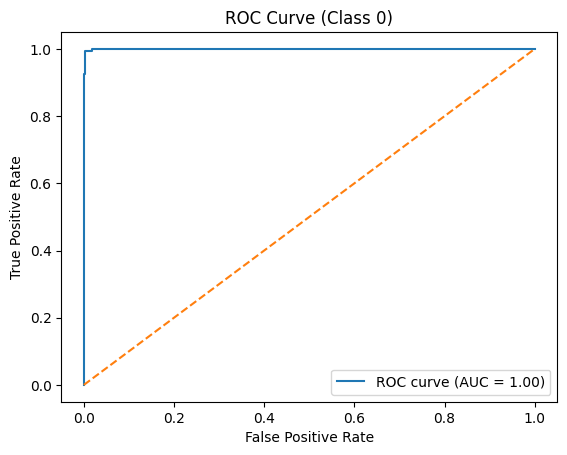

AUC Score: 0.9996775874478694


In [ ]:
# Required imports (add if not already done)
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_curve, auc
from sklearn import svm
import numpy as np
import matplotlib.pyplot as plt

# Binarize the output
y_test_bin = label_binarize(y_test, classes=np.unique(y_encoded))

# Train One-vs-Rest classifier
classifier = OneVsRestClassifier(svm.SVC(kernel='rbf', probability=True))
y_score = classifier.fit(X_train, y_train).decision_function(X_test)

# Compute ROC curve and AUC for class 0 (example)
fpr, tpr, _ = roc_curve(y_test_bin[:, 0], y_score[:, 0])
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, label="ROC curve (AUC = %0.2f)" % roc_auc)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Class 0)")
plt.legend(loc="lower right")
plt.show()

# Print AUC Score
print("AUC Score:", roc_auc)

In [ ]:
# =========================================
# STEP 1: Import Libraries
# =========================================
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix

# =========================================
# STEP 2: Load Dataset (iris.csv)
# =========================================
data = pd.read_csv("iris.csv")

# Display first few rows
print(data.head())

# =========================================
# STEP 3: Preprocessing
# =========================================
# Encode target column (species)
le = LabelEncoder()
data['species'] = le.fit_transform(data['species'])

# Features & Target
X = data.drop('species', axis=1)
y = data['species']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# =========================================
# STEP 4: Random Forest (Default n_estimators = 10)
# =========================================
rf_default = RandomForestClassifier(n_estimators=10, random_state=42)
rf_default.fit(X_train, y_train)

y_pred_default = rf_default.predict(X_test)

accuracy_default = accuracy_score(y_test, y_pred_default)
cm_default = confusion_matrix(y_test, y_pred_default)

print("\n=== Default Random Forest (10 Trees) ===")
print("Accuracy:", accuracy_default)
print("Confusion Matrix:\n", cm_default)

# =========================================
# STEP 5: Hyperparameter Tuning (Number of Trees)
# =========================================
best_accuracy = 0
best_n = 0
best_cm = None

for n in range(1, 101):   # try 1 to 100 trees
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    if acc > best_accuracy:
        best_accuracy = acc
        best_n = n
        best_cm = confusion_matrix(y_test, y_pred)

# =========================================
# STEP 6: Best Result
# =========================================
print("\n=== Best Model ===")
print("Best Accuracy:", best_accuracy)
print("Best Number of Trees:", best_n)
print("Confusion Matrix:\n", best_cm)

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

=== Default Random Forest (10 Trees) ===
Accuracy: 1.0
Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

=== Best Model ===
Best Accuracy: 1.0
Best Number of Trees: 1
Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
